# System Eval: Chronos2 on Original Dataset

This notebook mirrors `notebooks/visualize_eval.ipynb` but runs only **Chronos2 Zero-Shot** on **`data/data_original.csv`**.

Metrics are read from `results/evaluation/`; generated figures are saved to `results/plots/`.

In [3]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)
print('Python:', sys.executable)


Project root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
Python: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python


In [4]:
MODEL = 'chronos2'
DATASET_PATH = ROOT / 'data' / 'data_original.csv'
EVAL_DIR = ROOT / 'results' / 'evaluation'
PLOTS_DIR = ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Tune these as needed
HORIZON = 48
CONTEXT_LENGTH = 48
SAMPLING_MODE = 'random'
RANDOM_WINDOWS_PER_SERIES = 50
RANDOM_SEED = 42
RANDOM_WITH_REPLACEMENT = True
PAIRED_RANDOM_WINDOWS = True

cmd = [
    sys.executable,
    str(ROOT / 'src' / 'evaluate.py'),
    '--models', MODEL,
    '--data-path', str(DATASET_PATH),
    '--horizon', str(HORIZON),
    '--context-length', str(CONTEXT_LENGTH),
    '--sampling-mode', SAMPLING_MODE,
    '--random-windows-per-series', str(RANDOM_WINDOWS_PER_SERIES),
    '--random-seed', str(RANDOM_SEED),
    '--output-dir', str(EVAL_DIR),
]

if RANDOM_WITH_REPLACEMENT:
    cmd.append('--random-with-replacement')
else:
    cmd.append('--random-without-replacement')

if PAIRED_RANDOM_WINDOWS:
    cmd.append('--paired-random-windows')
else:
    cmd.append('--independent-random-windows')

print('Running:', ' '.join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
print('Evaluation completed for Chronos2 on:', DATASET_PATH)
print('Evaluation metrics folder:', EVAL_DIR)
print('Plots folder:', PLOTS_DIR)


Running: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/evaluate.py --models chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_original.csv --horizon 48 --context-length 48 --sampling-mode random --random-windows-per-series 50 --random-seed 42 --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation --random-with-replacement --paired-random-windows


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[chronos2] MAE_CP=1.8579 Coverage=0.9446 Sharpness=3.3520
Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/evaluation_summary.json
Evaluation completed for Chronos2 on: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_original.csv
Evaluation metrics folder: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation
Plots folder: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots


,model,dataset_path,MAE_CP,coverage_rate,sharpness,tolerance_hit_rate,num_windows_total,sampling_mode,random_windows_per_series,paired_random_windows
0,chronos2,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...,1.857907,0.944612,3.352043,0.855349,4300,random,50,True


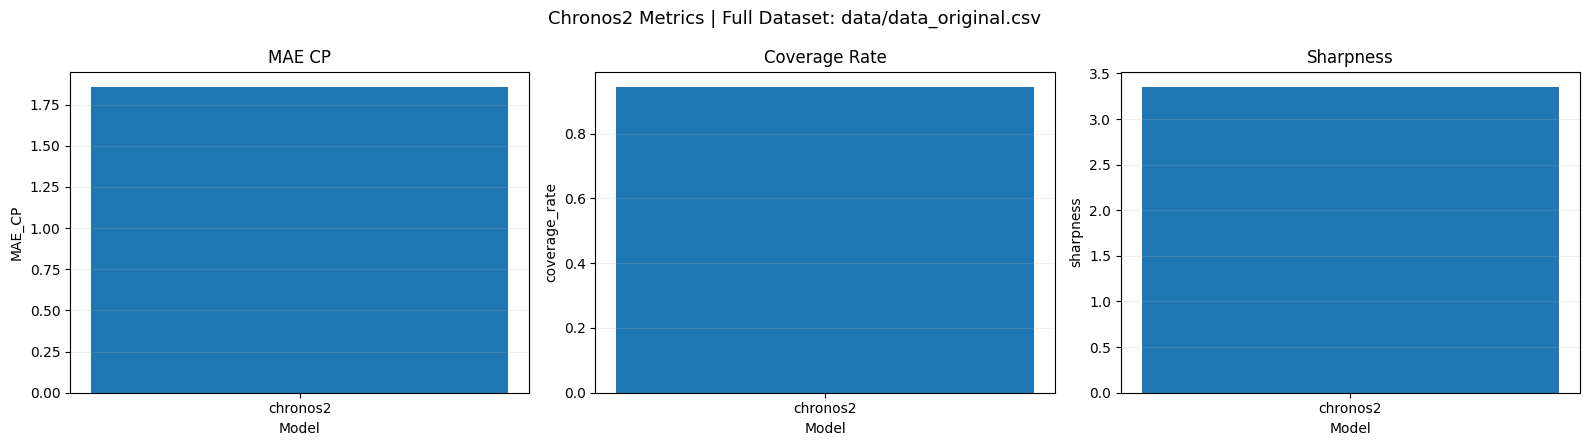

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/benchmark_chronos2_data_original.png


In [5]:
metrics_path = EVAL_DIR / 'chronos2_metrics.json'
if not metrics_path.exists():
    raise FileNotFoundError(f'Missing metrics file: {metrics_path}')

metrics = json.loads(metrics_path.read_text())
metrics_df = pd.DataFrame([
    {
        'model': metrics['model'],
        'dataset_path': metrics.get('dataset_path'),
        'MAE_CP': metrics['MAE_CP'],
        'coverage_rate': metrics['coverage_rate'],
        'sharpness': metrics['sharpness'],
        'tolerance_hit_rate': metrics['tolerance_hit_rate'],
        'num_windows_total': metrics['num_windows_total'],
        'sampling_mode': metrics.get('sampling_mode'),
        'random_windows_per_series': metrics.get('random_windows_per_series'),
        'paired_random_windows': metrics.get('paired_random_windows'),
    }
])
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_cols = ['MAE_CP', 'coverage_rate', 'sharpness']
titles = ['MAE CP', 'Coverage Rate', 'Sharpness']
for ax, col, title in zip(axes, metric_cols, titles):
    ax.bar([metrics['model']], [metrics[col]])
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Chronos2 Metrics | Full Dataset: data/data_original.csv', fontsize=13)
plt.tight_layout()
metrics_plot_path = PLOTS_DIR / 'benchmark_chronos2_data_original.png'
plt.savefig(metrics_plot_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved plot:', metrics_plot_path)


Selected series: ['T36870B', 'T78256A', 'T78259B']


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


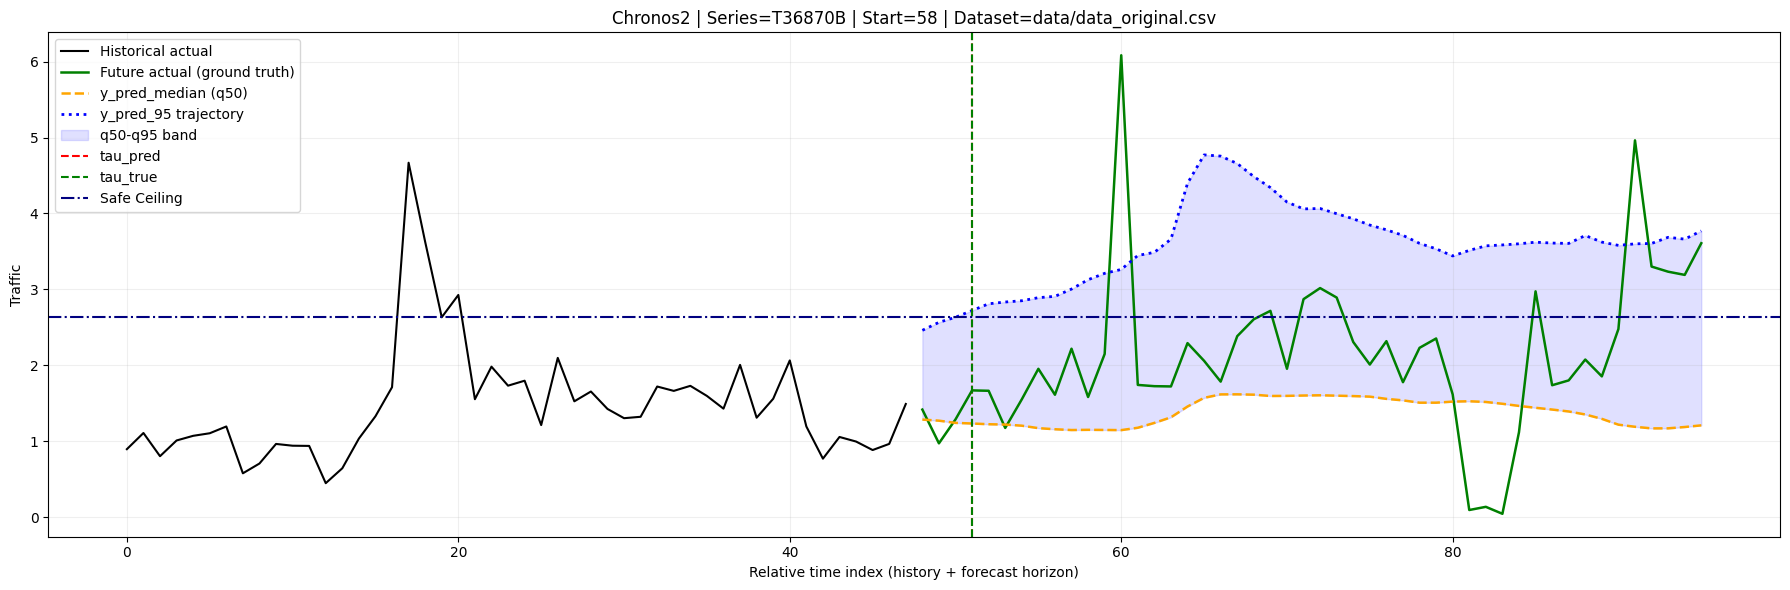

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/chronos2_original_T36870B_start58.png


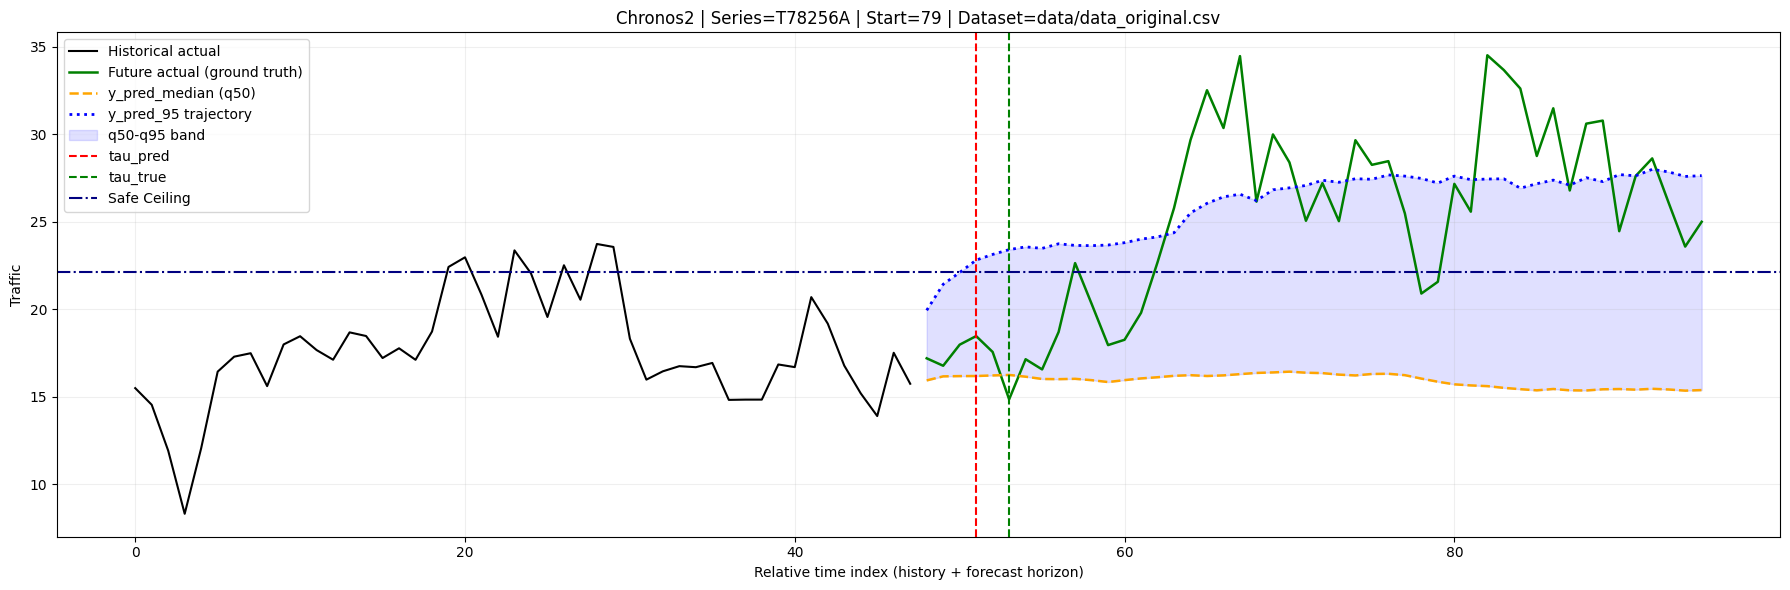

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/chronos2_original_T78256A_start79.png


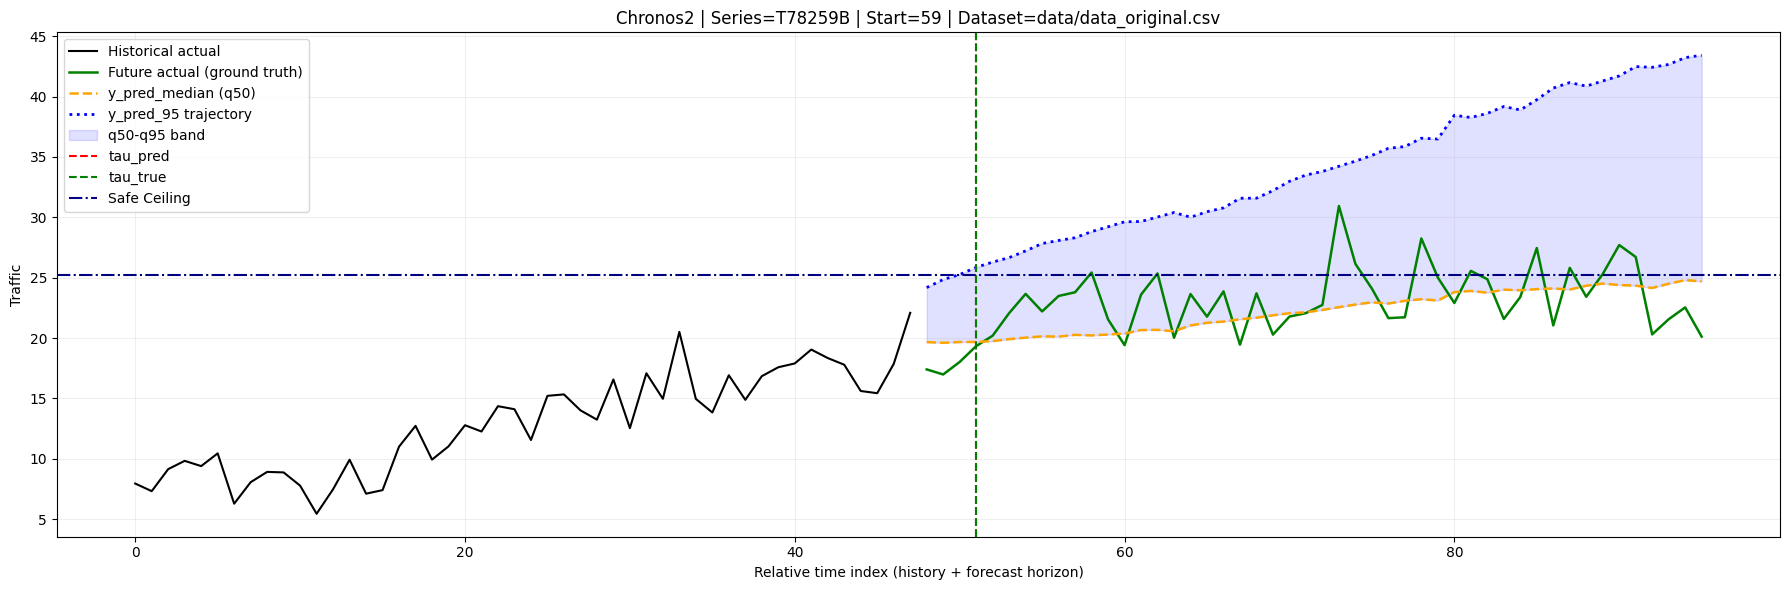

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/chronos2_original_T78259B_start59.png


In [6]:
from src.change_detection import RupturesPeltDetector
from src.pipeline import HybridForecastingChangePointPipeline, build_forecaster

RANDOM_SERIES_SEED = 123
N_SERIES_TO_PLOT = 3

full_df = pd.read_csv(DATASET_PATH)
windows_csv = EVAL_DIR / 'chronos2_window_metrics.csv'
if not windows_csv.exists():
    raise FileNotFoundError(f'Missing windows CSV: {windows_csv}')
windows_df = pd.read_csv(windows_csv)
if windows_df.empty:
    raise ValueError('Window metrics CSV is empty.')

available_series = sorted(windows_df['series'].unique().tolist())
rng = np.random.default_rng(RANDOM_SERIES_SEED)
num_to_plot = min(N_SERIES_TO_PLOT, len(available_series))
selected_series = sorted(rng.choice(available_series, size=num_to_plot, replace=False).tolist())
print('Selected series:', selected_series)

forecaster = build_forecaster(
    'chronos2',
    context_length=CONTEXT_LENGTH,
    forecast_length=HORIZON,
)
detector = RupturesPeltDetector(model='normal', penalty=3.0, min_size=3, jump=1)
pipeline = HybridForecastingChangePointPipeline(forecaster=forecaster, change_detector=detector)

for series_name in selected_series:
    series_windows = windows_df[windows_df['series'] == series_name]
    sampled_row = series_windows.sample(n=1, random_state=int(rng.integers(0, 1_000_000))).iloc[0]
    start = int(sampled_row['start_index'])

    values = pd.to_numeric(full_df[series_name], errors='coerce').to_numpy(dtype=float)
    history = values[start - CONTEXT_LENGTH:start]
    future_true = values[start:start + HORIZON]

    pred = pipeline.run(history=history, horizon=HORIZON)
    tau_true = detector.detect_first_change_point(future_true)

    hist_x = np.arange(CONTEXT_LENGTH)
    future_x = np.arange(CONTEXT_LENGTH, CONTEXT_LENGTH + HORIZON)

    plt.figure(figsize=(18, 6))
    plt.plot(hist_x, history, label='Historical actual', color='black', linewidth=1.5)
    plt.plot(future_x, future_true, label='Future actual (ground truth)', color='green', linewidth=1.8)
    plt.plot(future_x, pred.y_pred_median, label='y_pred_median (q50)', color='orange', linestyle='--', linewidth=1.8)
    plt.plot(future_x, pred.y_pred_95, label='y_pred_95 trajectory', color='blue', linestyle=':', linewidth=2.0)
    plt.fill_between(future_x, pred.y_pred_median, pred.y_pred_95, color='blue', alpha=0.12, label='q50-q95 band')

    if pred.tau_pred is not None:
        plt.axvline(CONTEXT_LENGTH + pred.tau_pred, color='red', linestyle='--', label='tau_pred')
    if tau_true is not None:
        plt.axvline(CONTEXT_LENGTH + tau_true, color='green', linestyle='--', label='tau_true')

    plt.axhline(pred.safe_ceiling, color='navy', linestyle='-.', linewidth=1.5, label='Safe Ceiling')
    plt.title(
        f'Chronos2 | Series={series_name} | Start={start} | Dataset=data/data_original.csv'
    )
    plt.xlabel('Relative time index (history + forecast horizon)')
    plt.ylabel('Traffic')
    plt.legend(loc='best')
    plt.grid(alpha=0.2)
    plt.tight_layout()

    out_path = PLOTS_DIR / f'chronos2_original_{series_name}_start{start}.png'
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved plot:', out_path)
